In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from random import choice, randint
from google.colab import files

plt.style.use('ggplot')

np.random.seed(42)

In [2]:
departments = [
    'HR',
    'IT',
    'Finance',
    'Sales',
    'Marketing',
    'Operations'
]

job_roles = [
    'Analyst',
    'Manager',
    'Executive',
    'Associate',
    'Specialist'
]

education = [
    'Bachelor',
    'Master',
    'MBA'
]

marital = [
    'Single',
    'Married'
]

employees = []

for i in range(1,201):

    emp_id = f"E{i:03}"

    emp_name = f"Employee_{i}"

    age = randint(22,60)

    gender = choice(['Male','Female'])

    dept = choice(departments)

    role = choice(job_roles)

    edu = choice(education)

    marital_status = choice(marital)

    years = randint(0,20)

    income = randint(25000,150000)

    performance = randint(1,5)

    satisfaction = randint(1,10)

    worklife = randint(1,10)

    training = randint(0,80)

    promotion = choice(['Yes','No'])

    overtime = choice(['Yes','No'])

    attrition = np.random.choice(
        ['Yes','No'],
        p=[0.25,0.75]
    )

    reason = choice([
        'Salary',
        'Workload',
        'Career Growth',
        'Relocation',
        'Management',
        'None'
    ])

    manager_rating = randint(1,5)

    engagement = randint(1,10)

    employees.append([
        emp_id,
        emp_name,
        age,
        gender,
        dept,
        role,
        edu,
        marital_status,
        years,
        income,
        performance,
        satisfaction,
        worklife,
        training,
        promotion,
        overtime,
        attrition,
        reason,
        manager_rating,
        engagement
    ])

df = pd.DataFrame(
    employees,
    columns=[
        'Employee_ID',
        'Employee_Name',
        'Age',
        'Gender',
        'Department',
        'Job_Role',
        'Education_Level',
        'Marital_Status',
        'Years_at_Company',
        'Monthly_Income',
        'Performance_Rating',
        'Job_Satisfaction',
        'WorkLife_Balance',
        'Training_Hours',
        'Promotion_Status',
        'Overtime_Status',
        'Attrition_Status',
        'Attrition_Reason',
        'Manager_Rating',
        'Employee_Engagement'
    ]
)

df.head()

,Employee_ID,Employee_Name,Age,Gender,Department,Job_Role,Education_Level,Marital_Status,Years_at_Company,Monthly_Income,Performance_Rating,Job_Satisfaction,WorkLife_Balance,Training_Hours,Promotion_Status,Overtime_Status,Attrition_Status,Attrition_Reason,Manager_Rating,Employee_Engagement
0,E001,Employee_1,48,Male,IT,Analyst,Bachelor,Single,19,30287,4,1,6,80,Yes,No,No,Salary,4,2
1,E002,Employee_2,22,Male,Operations,Specialist,MBA,Single,9,42371,1,2,6,72,No,Yes,No,Salary,4,5
2,E003,Employee_3,23,Male,Sales,Executive,Bachelor,Married,6,123173,2,7,2,33,Yes,No,No,Management,5,5
3,E004,Employee_4,29,Female,Operations,Executive,Master,Single,6,123244,5,9,8,16,No,No,No,Salary,4,2
4,E005,Employee_5,32,Male,HR,Executive,Master,Married,5,51372,4,4,4,52,No,Yes,Yes,Salary,1,5


In [3]:
df.to_csv(
    "HR_Raw_Dataset.csv",
    index=False
)

files.download(
    "HR_Raw_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
df['Attrition_Flag'] = np.where(
    df['Attrition_Status']=='Yes',
    1,
    0
)

df['Retention_Flag'] = np.where(
    df['Attrition_Status']=='No',
    1,
    0
)

In [5]:
df.to_csv(
    "HR_Processed_Dataset.csv",
    index=False
)

files.download(
    "HR_Processed_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
total_employees = len(df)

attrition_rate = round(
    (
        df['Attrition_Flag'].sum()
        /
        total_employees
    )*100,
    2
)

retention_rate = round(
    (
        df['Retention_Flag'].sum()
        /
        total_employees
    )*100,
    2
)

avg_salary = round(
    df['Monthly_Income'].mean(),
    2
)

avg_satisfaction = round(
    df['Job_Satisfaction'].mean(),
    2
)

avg_engagement = round(
    df['Employee_Engagement'].mean(),
    2
)

kpi = pd.DataFrame({

'Metric':[
'Total Employees',
'Attrition Rate',
'Retention Rate',
'Average Salary',
'Average Satisfaction',
'Average Engagement'
],

'Value':[
total_employees,
attrition_rate,
retention_rate,
avg_salary,
avg_satisfaction,
avg_engagement
]

})

kpi

,Metric,Value
0,Total Employees,200.00
1,Attrition Rate,28.00
2,Retention Rate,72.00
3,Average Salary,87327.30
4,Average Satisfaction,5.44
5,Average Engagement,5.28


In [7]:
kpi.to_csv(
    "HR_KPI_Report.csv",
    index=False
)

files.download(
    "HR_KPI_Report.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

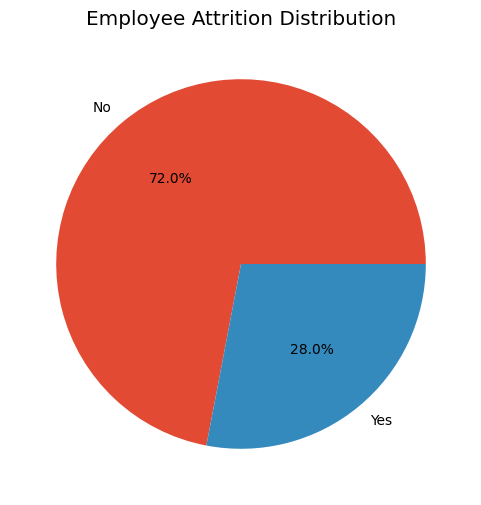

In [8]:
attrition_counts = (
    df['Attrition_Status']
    .value_counts()
)

plt.figure(figsize=(6,6))

plt.pie(
    attrition_counts,
    labels=attrition_counts.index,
    autopct='%1.1f%%'
)

plt.title(
    "Employee Attrition Distribution"
)

plt.savefig(
    "Chart1_Attrition_Distribution.png",
    bbox_inches='tight'
)

plt.show()

In [9]:
files.download(
    "Chart1_Attrition_Distribution.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

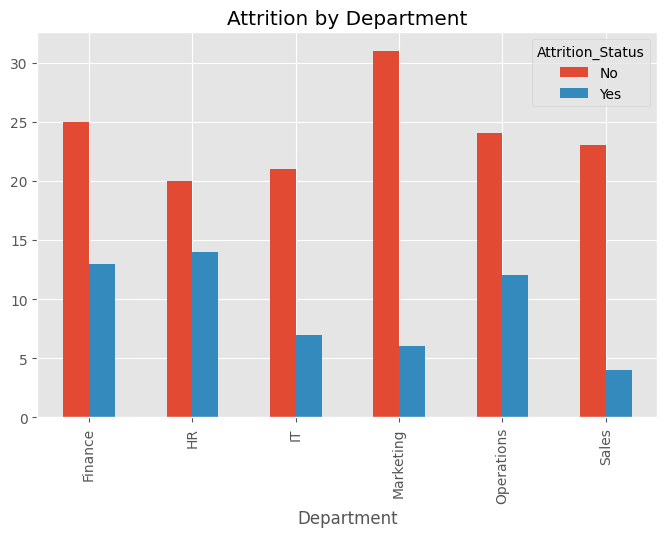

In [10]:
dept_attrition = pd.crosstab(
    df['Department'],
    df['Attrition_Status']
)

dept_attrition.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Attrition by Department"
)

plt.savefig(
    "Chart2_Department_Attrition.png",
    bbox_inches='tight'
)

plt.show()

In [11]:
files.download(
    "Chart2_Department_Attrition.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

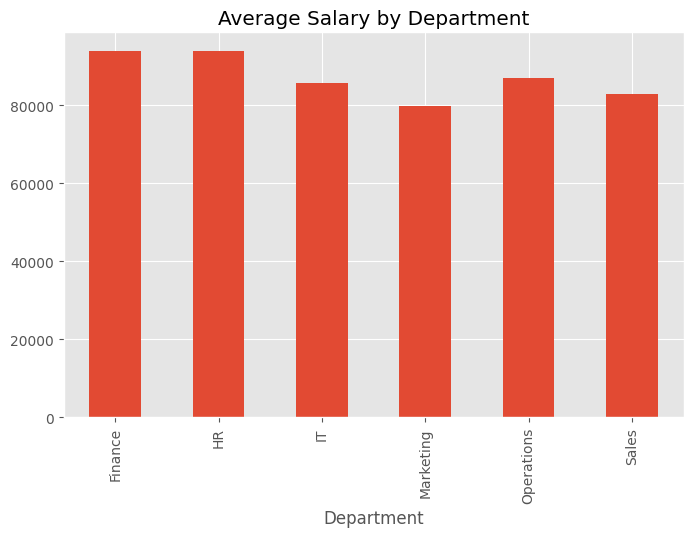

In [12]:
salary_dept = df.groupby(
    'Department'
)['Monthly_Income'].mean()

salary_dept.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Average Salary by Department"
)

plt.savefig(
    "Chart3_Salary_Department.png",
    bbox_inches='tight'
)

plt.show()

In [13]:
files.download(
    "Chart3_Salary_Department.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

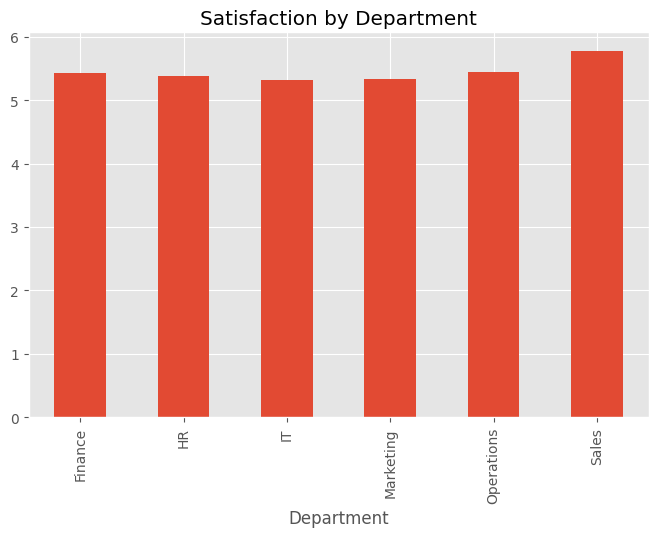

In [14]:
sat = df.groupby(
    'Department'
)['Job_Satisfaction'].mean()

sat.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    "Satisfaction by Department"
)

plt.savefig(
    "Chart4_Satisfaction_Department.png",
    bbox_inches='tight'
)

plt.show()

In [15]:
files.download(
    "Chart4_Satisfaction_Department.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

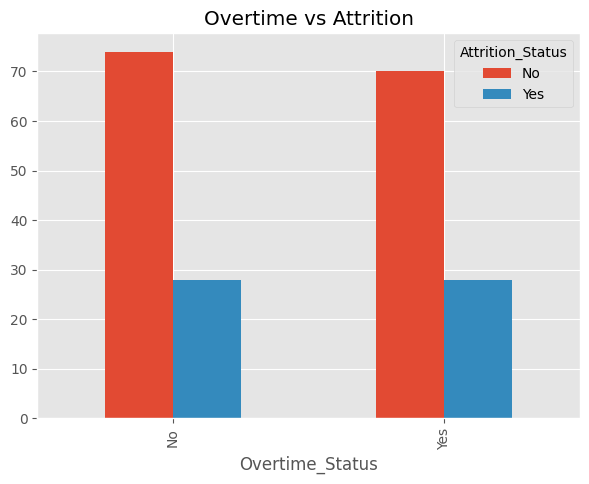

In [16]:
ot = pd.crosstab(
    df['Overtime_Status'],
    df['Attrition_Status']
)

ot.plot(
    kind='bar',
    figsize=(7,5)
)

plt.title(
    "Overtime vs Attrition"
)

plt.savefig(
    "Chart5_Overtime_Attrition.png",
    bbox_inches='tight'
)

plt.show()

In [17]:
files.download(
    "Chart5_Overtime_Attrition.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

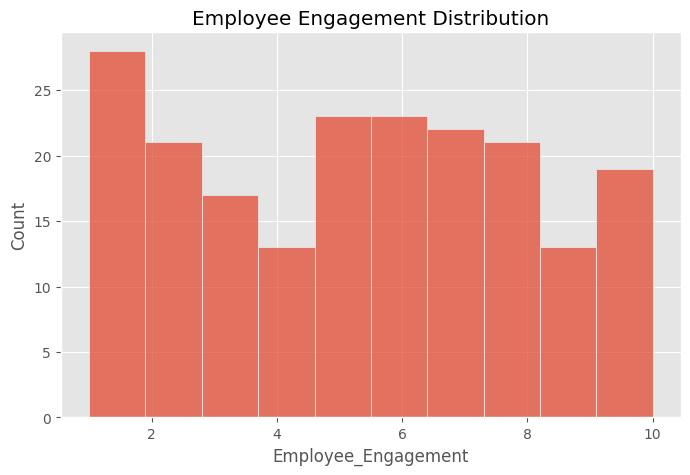

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Employee_Engagement'],
    bins=10
)

plt.title(
    "Employee Engagement Distribution"
)

plt.savefig(
    "Chart6_Engagement_Distribution.png",
    bbox_inches='tight'
)

plt.show()

In [19]:
files.download(
    "Chart6_Engagement_Distribution.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

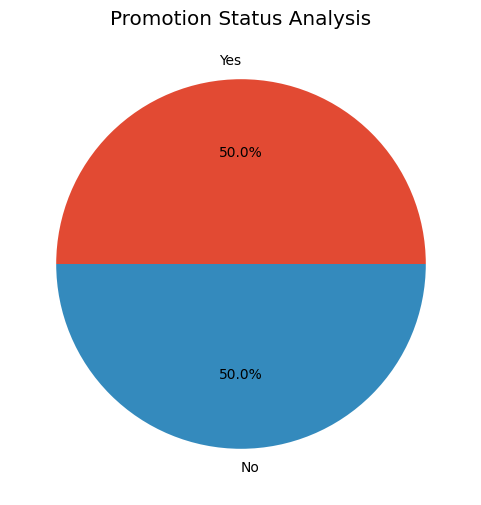

In [20]:
promotion = (
    df['Promotion_Status']
    .value_counts()
)

promotion.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.ylabel("")

plt.title(
    "Promotion Status Analysis"
)

plt.savefig(
    "Chart7_Promotion_Analysis.png",
    bbox_inches='tight'
)

plt.show()

In [21]:
files.download(
    "Chart7_Promotion_Analysis.png"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

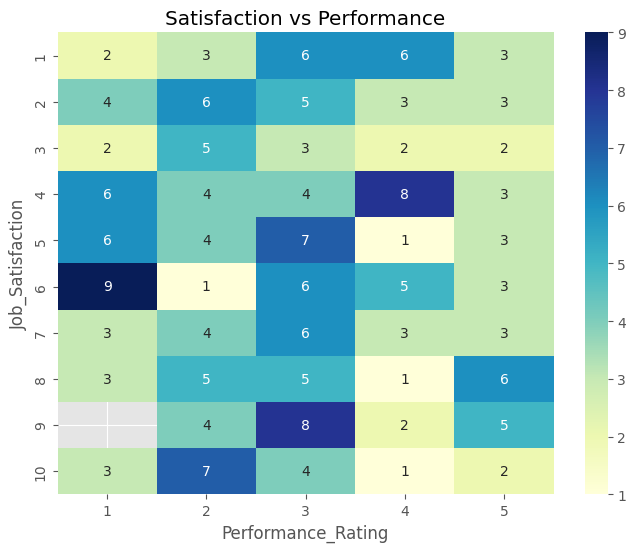

In [22]:
heat = pd.pivot_table(
    df,
    values='Employee_ID',
    index='Job_Satisfaction',
    columns='Performance_Rating',
    aggfunc='count'
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heat,
    annot=True,
    cmap='YlGnBu'
)

plt.title(
    "Satisfaction vs Performance"
)

plt.savefig(
    "Chart8_Satisfaction_Performance.png",
    bbox_inches='tight'
)

plt.show()

In [23]:
df.to_csv(
    "Final_HR_Analytics_Dataset.csv",
    index=False
)

files.download(
    "Final_HR_Analytics_Dataset.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>